
# Demo de `barley-gblup`

Este cuaderno muestra una librería de Python con:

- un estimador `GBLUPRegressor` con interfaz tipo `scikit-learn`;
- un simulador de datos sintéticos, grandes pero manejables, inspirado en el artículo sobre cebada.

El conjunto sintético reproduce, de forma aproximada, varios rasgos estructurales del artículo:

- 1.110 genotipos;
- cuatro grupos: `Elite_Spring`, `Elite_Winter`, `PGR_Spring`, `PGR_Winter`;
- siete rasgos: `HD`, `PLH`, `LOD`, `BLU`, `PUC`, `RHY` y `RAM`;
- correlación debida a estructura poblacional y desequilibrio de ligamiento local.


In [1]:

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from barley_gblup import GBLUPRegressor, simulate_barley_article_dataset

rng = 42


In [2]:

sim = simulate_barley_article_dataset(n_snps=8000, random_state=rng, return_numpy=True)

X = sim["X"]
pheno = sim["phenotype"].copy()
meta = sim["metadata"].copy()

print(X.shape)
print(pheno.head())


(1110, 8000)
  sample_id         group  panel  season        HD       PLH  LOD  BLU  PUC  \
0     G0001  Elite_Spring  Elite  Spring -2.788238 -0.269256    2    3    6   
1     G0002  Elite_Spring  Elite  Spring -0.867792 -0.729471    6    3    1   
2     G0003  Elite_Spring  Elite  Spring -0.810176  1.931189    5    4    4   
3     G0004  Elite_Spring  Elite  Spring -0.258428 -1.689904    3    6    3   
4     G0005  Elite_Spring  Elite  Spring -1.748898 -0.564086    3    3    1   

   RHY  RAM  integrated_subset  
0    6    6               True  
1    1    5               True  
2    6    8               True  
3    1    8               True  
4    3    8               True  


## Resumen del conjunto simulado

In [3]:

summary = {
    "n_genotipos": X.shape[0],
    "n_snps": X.shape[1],
    "grupos": meta["group"].value_counts().to_dict(),
    "subset_integrado": pheno["integrated_subset"].value_counts().to_dict(),
}
summary


{'n_genotipos': 1110,
 'n_snps': 8000,
 'grupos': {'PGR_Winter': 524,
  'PGR_Spring': 288,
  'Elite_Winter': 170,
  'Elite_Spring': 128},
 'subset_integrado': {True: 874, False: 236}}

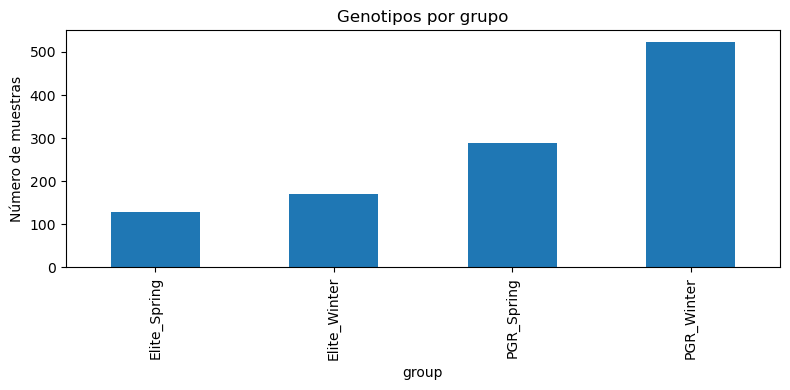

In [4]:

fig, ax = plt.subplots(figsize=(8, 4))
meta["group"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Genotipos por grupo")
ax.set_ylabel("Número de muestras")
plt.tight_layout()
plt.show()


In [5]:

trait_cols = ["HD", "PLH", "LOD", "BLU", "PUC", "RHY", "RAM"]
pheno[trait_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
HD,1110.0,-0.362007,1.599308,-5.314815,-1.554565,-0.366352,0.822027,3.917677
PLH,1110.0,1.039461,2.059026,-4.132157,-0.541013,1.046309,2.607253,6.448841
LOD,1110.0,5.000000,2.585246,1.000000,3.000000,5.000000,7.000000,9.000000
BLU,1110.0,5.000000,2.585246,1.000000,3.000000,5.000000,7.000000,9.000000
PUC,1110.0,5.000000,2.585246,1.000000,3.000000,5.000000,7.000000,9.000000
RHY,1110.0,5.000000,2.585246,1.000000,3.000000,5.000000,7.000000,9.000000
RAM,1110.0,5.000000,2.585246,1.000000,3.000000,5.000000,7.000000,9.000000


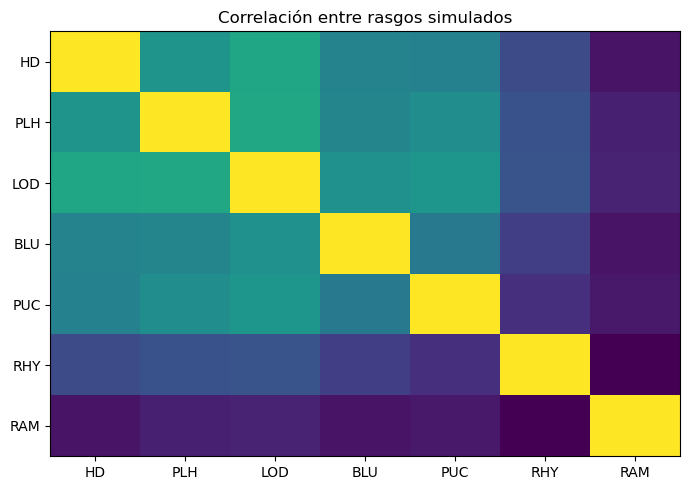

In [6]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(pheno[trait_cols].corr(), aspect="auto")
ax.set_xticks(range(len(trait_cols)))
ax.set_xticklabels(trait_cols)
ax.set_yticks(range(len(trait_cols)))
ax.set_yticklabels(trait_cols)
ax.set_title("Correlación entre rasgos simulados")
plt.tight_layout()
plt.show()


## Ajuste de GBLUP para un rasgo continuo

In [7]:

mask = pheno["integrated_subset"].to_numpy()
X_int = X[mask]
y_plh = pheno.loc[mask, "PLH"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_int, y_plh, test_size=0.2, random_state=rng
)

model = GBLUPRegressor(grm="vanraden", optimize_delta=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred)
corr = np.corrcoef(y_test, y_pred)[0, 1]
print({"RMSE": rmse, "corr": corr, "delta": model.delta_})


{'RMSE': 1.7333515248074234, 'corr': np.float64(0.7567274584199699), 'delta': 0.3221397662217866}


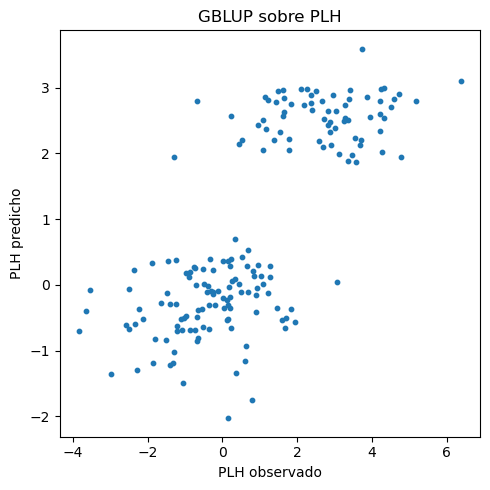

In [8]:

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, s=10)
ax.set_xlabel("PLH observado")
ax.set_ylabel("PLH predicho")
ax.set_title("GBLUP sobre PLH")
plt.tight_layout()
plt.show()


## Comparación con otros modelos

In [9]:

cv = KFold(n_splits=5, shuffle=True, random_state=rng)

models = {
    "GBLUP": GBLUPRegressor(grm="vanraden", optimize_delta=True),
    "RidgeCV": RidgeCV(alphas=np.logspace(-2, 2, 10)),
    "RandomForest": RandomForestRegressor(
        n_estimators=150, max_depth=18, min_samples_leaf=2, n_jobs=-1, random_state=rng
    ),
    "SVM_PCA": Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=60, random_state=rng)),
        ("svr", SVR(C=3.0, epsilon=0.1, kernel="rbf")),
    ]),
}

rows = []
for name, estimator in models.items():
    scores = cross_validate(
        estimator,
        X_int,
        y_plh,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
        return_train_score=False,
    )
    rows.append({
        "model": name,
        "rmse_mean": -scores["test_rmse"].mean(),
        "rmse_sd": scores["test_rmse"].std(),
        "r2_mean": scores["test_r2"].mean(),
        "r2_sd": scores["test_r2"].std(),
    })

results = pd.DataFrame(rows).sort_values("rmse_mean")
results


,model,rmse_mean,rmse_sd,r2_mean,r2_sd
0,GBLUP,1.327373,0.023430,0.551675,0.038635
1,RidgeCV,1.345074,0.024973,0.539569,0.040574
2,RandomForest,1.416243,0.039009,0.490935,0.026388
3,SVM_PCA,1.553498,0.066237,0.384591,0.075593


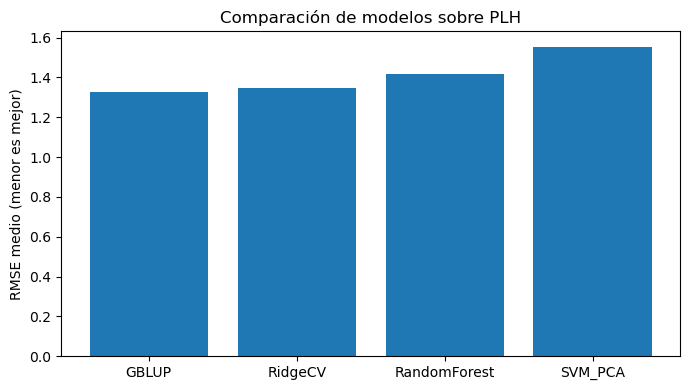

In [10]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results["model"], results["rmse_mean"])
ax.set_ylabel("RMSE medio (menor es mejor)")
ax.set_title("Comparación de modelos sobre PLH")
plt.tight_layout()
plt.show()


## Rasgo ordinal tratado como continuo

In [11]:

y_lod = pheno.loc[mask, "LOD"].to_numpy().astype(float)

lod_cv = cross_validate(
    GBLUPRegressor(grm="vanraden", optimize_delta=True),
    X_int,
    y_lod,
    cv=cv,
    scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
    n_jobs=1,
)

print({
    "LOD_rmse_mean": -lod_cv["test_rmse"].mean(),
    "LOD_r2_mean": lod_cv["test_r2"].mean(),
})


{'LOD_rmse_mean': np.float64(1.4620177629826707), 'LOD_r2_mean': np.float64(0.6571667624613591)}



## Comentarios

- El estimador `GBLUPRegressor` se usa como cualquier regresor de `scikit-learn`.
- El simulador genera un conjunto suficientemente grande para probar validación cruzada y comparar modelos.
- En un análisis real del artículo convendría añadir control explícito de estructura poblacional, por ejemplo con componentes principales como efectos fijos, y separar primavera e invierno.
